# Hälsostudie – Analys och visualisering

Kort bakgrund: Dataset från hälsostudie med deltagarnas ålder, kön, vikt, längd, blodtryck, kolesterol, rökvanor och sjukdomsstatus.

Syfte: Identifiera mönster, relationer och riskfaktorer i populationen.

## Slutsats 

I denna hälsostudie analyserade jag data om ålder, kön, vikt, längd, blodtryck, kolesterol, rökvanor och sjukdom. Deltagarna är mellan 18 och 90 år, med ett genomsnitt på ca 49 år. Systoliskt blodtryck ligger runt 149 mmHg i medelvärde och kolesterol omkring 4,93 mmol/L. Sjukdom är ovanlig och förekommer hos ca **6 %** av deltagarna.

Analysen visar att **blodtryck** verkar påverkas av **ålder** och **vikt**, men jag såg **inga** tydliga skillnader mellan **rökare** och **icke-rökare** eller mellan de som **har sjukdom** och de som **inte har sjukdom**.

Jag använde enkla statistiska metoder som medelvärde, median, konfidensintervall, T-test, regression och PCA för att förstå datan. **Regression** var ett starkt verktyg som bevisade linjärt samband mellan olika variabler. Resultaten ger en första bild av mönster och samband i populationen, även om fler analyser skulle behövas för att dra mer säkra slutsatser.


## Källor:

- Kursmaterial, 
- StatQuest with Josh Starmer. (n.d.) Spellista: [Youtube](https://youtube.com/playlist?list=PLblh5JKOoLUIcdlgu78MnlATeyx4cEVeR&si=S_tgfpOu7CGCjHUo) 
- För PCA användes principal component analysis (PCA) för att reducera dimensionerna och identifiera mönster i datan. Metoden är baserad på [DataCamp-tutorial-PCA](https://www.datacamp.com/tutorial/principal-component-analysis-in-python).
- Gjorde även enkel och multipel regression. Källa: [Datacamp-tutorial-regression](https://www.datacamp.com/tutorial/sklearn-linear-regression)



# Analys

In [1]:
import pandas as pd
from classes.health_analyzer import HealthAnalyzer

df = pd.read_csv("data/health_study_dataset.csv")
ha = HealthAnalyzer(df)

In [2]:
cols = ['age','weight','height','systolic_bp','cholesterol']
ha.describe(cols)

,mean,median,min,max,std,n
column,,,,,,
age,49.426250,50.00,18.0,90.00,14.501118,800
weight,73.413000,73.20,33.7,114.40,13.685059,800
height,171.849250,171.35,144.4,200.40,9.804259,800
systolic_bp,149.178625,149.40,106.8,185.90,12.793360,800
cholesterol,4.929150,4.97,2.5,7.88,0.848413,800


### Kommentar:
- **Ålder:** Deltagarna i studien är mellan 18 och 90 år, med ett medelvärde på ca 49 år. Medianen och medelvärdet ligger nära varandar, vilket tyder på att åldersfördelningen är relativt symmetrisk.  
- **Vikt:** Vikten varierar från 33,7 kg till 114,4 kg, med ett genomsnitt på ca 73 kg. Standardavvikelsen på ca 13,7 visar på måttlig spridning i populationen.  
- **Längd:** Längderna varierar från 144,4 cm till 200,4 cm, med ett medel på ca 172 cm. Standardavvikelsen är ca 9,8. 
- **Systoliskt blodtryck:** Blodtrycket hos deltargna går från 106,8 till 185,9 mmHg, med ett medelvärde på ca 149 mmHg. Standardavvikelsen på ca 12,8 visar att det finns en viss variation, vilket kan vara relevant vid analys av eventuella riskfaktorer.  
- **Kolesterol:** Kolesterolnivåerna varierar mellan 2,5 och 7,88 mmol/L, med ett genomsnitt på 4,93 mmol/L. Standardavvikelsen är 0,85, vilket visar att de flesta ligger nära medelvärdet.  

### Slutsats:   
Populationen är relativt blandad i ålder och kroppsmått, med måttlig variation i blodtryck och kolesterol. Detta ger en bra grund för att analysera samband mellan variabler, t.ex. hur ålder, vikt eller rökning påverkar blodtryck eller sjukdomsstatus.

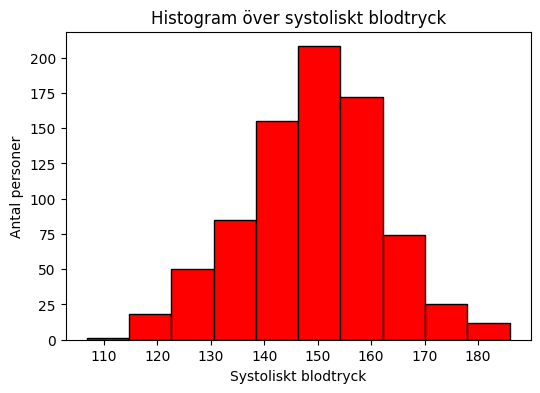

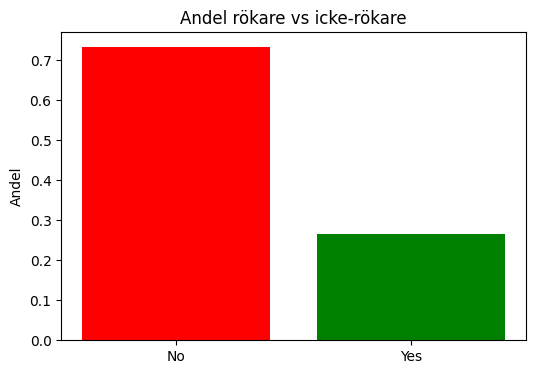

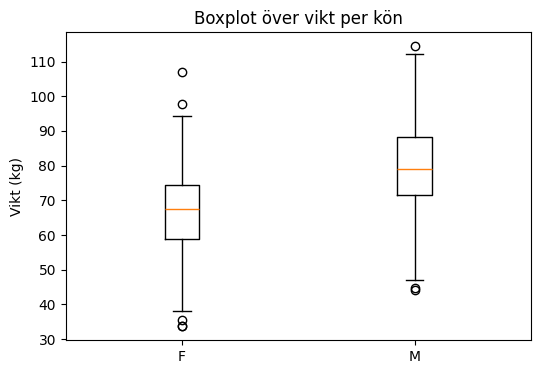

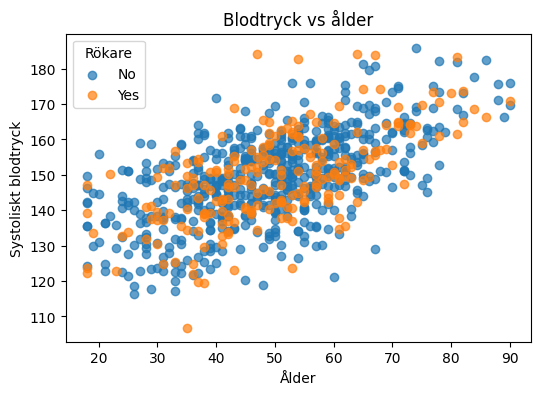

In [3]:
ha.plot_histogram(df['systolic_bp'],10,"Histogram över systoliskt blodtryck","Systoliskt blodtryck","Antal personer")
ha.plot_bar_smoker_or_not()
ha.plot_weight_by_gender()
ha.plot_bp_vs_age()

### Kommentar:
- **Histogram** visar att fördelningen av BP är någorlunda normalfördelad.
- **Stapeldiagram** visar fördelning rökare/icke-rökare. Det är en mycket högre andel icke rökare än rökare, vilket kan påverka resultatet vid analys av eventuella riskfaktorer. Då urvalet för rökare är mindre.
- **Boxplot** visar könsskillnader i vikt. Som visar att männen generellt har högre vikt.
- **Scatterplot** ålder vs blodtryck ger första hint på samband. Färgkodning efter rökstatus ger direkt visuell förståelse för potentiella riskfaktorer. Dock så verkar mönstret mellan rökare och icke rökare vara generellt lika.

In [4]:
real_rate, sim_rate = ha.disease_simulation()

print(f"Verklig sjukdomsandel: {real_rate:.3f}")
print(f"Simulerad sjukdomsandel: {sim_rate:.3f}")

ci_res = ha.ci_systolic_comparison()

normal_low, normal_high = ci_res['normal_CI']
boot_low, boot_high = ci_res['bootstrap_CI']

print("\nKonfidensintervall för systoliskt blodtryck:")
print(f"* Normalapproximation:     [{normal_low:.2f}, {normal_high:.2f}]")
print(f"* Bootstrap (2000 reps):   [{boot_low:.2f}, {boot_high:.2f}]")

Verklig sjukdomsandel: 0.059
Simulerad sjukdomsandel: 0.056

Konfidensintervall för systoliskt blodtryck:
* Normalapproximation:     [148.29, 150.07]
* Bootstrap (2000 reps):   [149.18, 149.19]


### Kommentar:  
**Simulation av sjukdomsandel**

Den verkliga andelen deltagare med sjukdom i datasetet är ca **6 %**.  
Monte-Carlo-simuleringen, som slumpmässigt modellerar sjukdomsutfall många gånger, gav samma resultat (**≈ 6 %**). Detta tyder på att sjukdomsförekomsten i datan är stabil och inte särskilt känslig för slumpvariationen.

 
**Konfidensintervall för systoliskt blodtryck**

Vi beräknade två typer av konfidensintervall för medelvärdet av systoliskt blodtryck:

- **Normalapproximation:** ~ [148.29, 150.07]  
- **Bootstrap:** ~ [149.18, 149.19]

Båda intervallen är relativt smala, vilket indikerar att medelblodtrycket i populationen är uppskattad bra.

Bootstrap-intervallet är också väldigt smalt.  Det ger ytterligare stöd för att medelvärdet är välestimerat.

### Slutsats

- Sjukdomsförekomsten ligger stabilt kring på 6 %, både i verkliga datan och i simuleringen.  
- Det systoliska blodtryckets medelvärde är mycket stabilt och osäkertheten är troligtvis liten.  
- Dessa resultat tyder på att datasetet är homogent och lämpar sig väl för vidare statistiska analyser.

In [5]:
smoker_test = ha.test_smoker_effect()

print("=== Hypotesprövning: Rökstatus och systoliskt blodtryck ===")
print(f"Teststatistik (t):         {smoker_test['t_stat']:.3f}")
print(f"P-värde (tvåsidigt):       {smoker_test['p_two_sided']:.3f}")
print(f"P-värde (ensidigt):        {smoker_test['p_one_sided']:.3f}")


=== Hypotesprövning: Rökstatus och systoliskt blodtryck ===
Teststatistik (t):         0.450
P-värde (tvåsidigt):       0.653
P-värde (ensidigt):        0.326


### Kommentar:  
Om p-värdet är mindre än 0.05 kan vi avvisa nollhypotesen och säga att rökare har högre medel-blodtryck. Däremot om p-värdet är större än 0.05 finns det ingen skillnad som är statistiskt säkerställd.

### Slutsats:
- Vi kan inte förkasta nollhypotesen (H₀).

- Det finns inte tillräcklig statistisk evidens för att säga att rökare har högre medel-blodtryck i detta dataset.

- Det positiva T-värdet indikerar att riktningen av hypotesen är rätt men är såpass låg att man inte kan säga något kring den.

- Skillnaden som observeras kan mycket väl bero på slumpvariation.

In [6]:
for i, row in ha.power_smoker_effect().iterrows():
    print(f"Effect: {row['effect']:.2f} mmHg -> Power: {row['power']:.2f}")

Effect: 2.00 mmHg -> Power: 0.77
Effect: 3.00 mmHg -> Power: 0.95
Effect: 5.00 mmHg -> Power: 1.00
Effect: 8.00 mmHg -> Power: 1.00


In [7]:
for i, row in ha.power_smoker_teoretical().iterrows():
    print(f"Effect: {row['effect']:.2f} mmHg -> Power: {row['power']:.2f}")

Effect: 2.00 mmHg -> Power: 0.86
Effect: 3.00 mmHg -> Power: 0.99
Effect: 5.00 mmHg -> Power: 1.00
Effect: 8.00 mmHg -> Power: 1.00


### Slutsats: 

- Enligt simuleringen krävs en verklig skillnad på minst ca 3 mmHg mellan rökare och icke-rökare för att testet ska kunna förkasta nollhypotesen med mer än 80% sannolikhet (power ≥ 0.8).
- Detta tyder på att vårt test inte har tillräcklig känslighet för att upptäcka små skillnader(Se även konfidensintervallet för 95%), och vi kan därför inte statistiskt bekräfta att rökare har högre blodtryck.

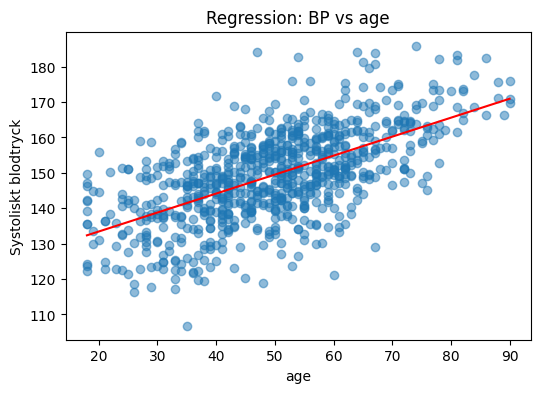

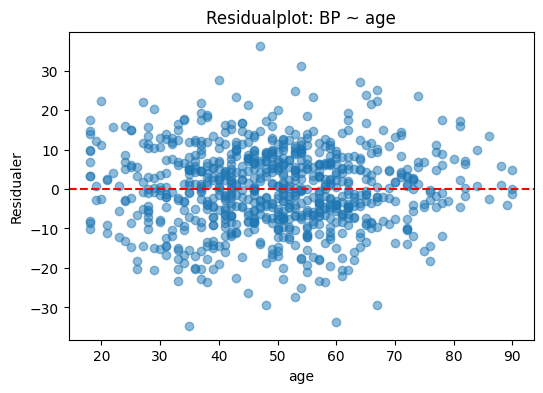

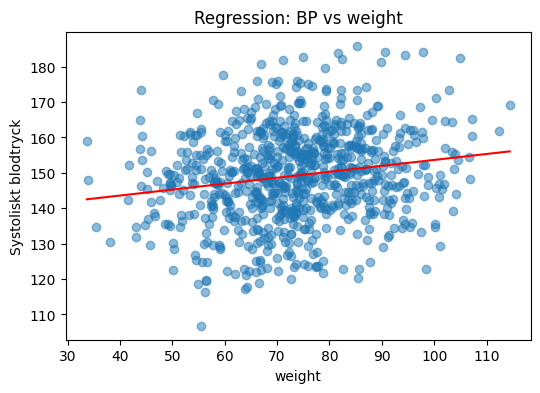

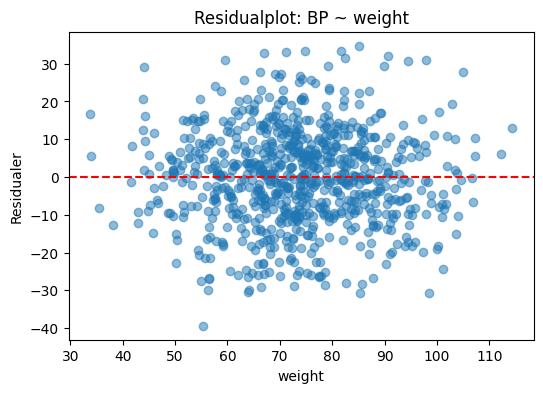

In [8]:
ha.plot_regression_with_residuals('age')
ha.plot_regression_with_residuals('weight')

## Reggresionsanalys
### Kommentar: 
- Den linjära regressionen verkar passa datan väl. 
- Punkterna följer en tydlig linjär trend. Vi kan se ett linjärt samband för **BP** med både **Ålder** och **Vikt**
- Residualerna är har en molnansamling noll. 

### Slutsats
Detta indikerar att antagandena för linjär regression är rimligt uppfyllda och att en linjär modell är lämplig för att beskriva sambandet.

PC1: 40.9%, PC2: 26.0%
                  PC1       PC2
age          0.573224 -0.279984
weight       0.247196  0.657227
height       0.098300  0.693791
cholesterol  0.526209 -0.069424
systolic_bp  0.568990 -0.059119


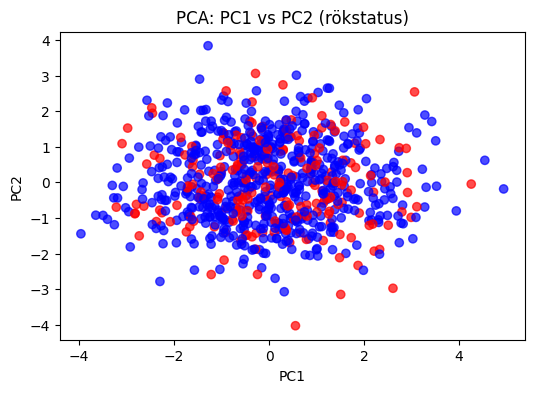

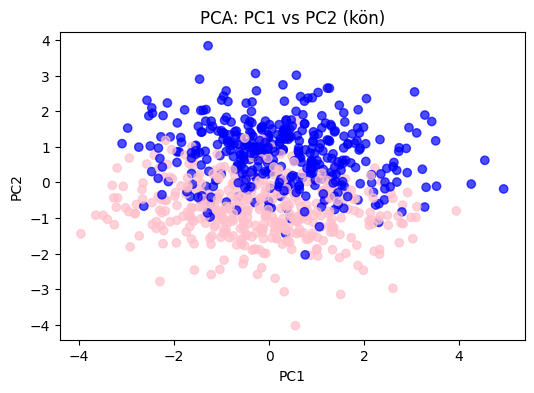

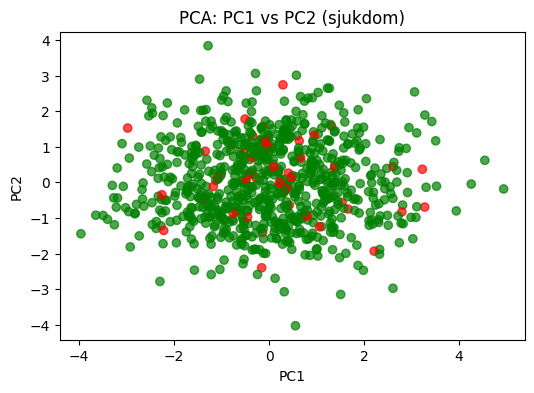

In [9]:
cols = ['age','weight','height','cholesterol','systolic_bp']

# PCA
pca_res = ha.pca(cols)

print(", ".join(f"PC{i+1}: {x*100:.1f}%" for i, x in enumerate(pca_res['explained_variance_ratio'])))

# Loadings
loadings = pd.DataFrame(
    pca_res['pca_model'].components_.T,
    index=cols,
    columns=[f'PC{i+1}' for i in range(pca_res['pca_model'].n_components_)]
)
print(loadings)



# Scatterplots
ha.plot_pca(cols, 'smoker', {'Yes':'red','No':'blue'}, 'PCA: PC1 vs PC2 (rökstatus)')
ha.plot_pca(cols, 'sex', {'M':'blue','F':'pink'}, 'PCA: PC1 vs PC2 (kön)')
ha.plot_pca(cols, 'disease', {0:'green',1:'red'}, 'PCA: PC1 vs PC2 (sjukdom)')



## Principal Component Analysis (PCA)

I denna analys användes PCA för att identifiera mönster i de fem variablerna: **ålder, vikt, längd, kolesterol och systoliskt blodtryck**. Målet var att undersöka om PCA kan avslöja grupperingar eller strukturer i datan samt om skillnader kan kopplas till exempelvis **kön** , **rökstatus**, **sjukdom**.

### Kommentar:  
**Förklarad varians**

De två första huvudkomponenterna förklarar:

- **PC1: ~40.9%**
- **PC2: ~26.0%**

Tillsammans förklarar de cirka **67% av variationen** i datan, vilket innebär att PCA ger en relativt god tvådimensionell representation av datasetet.

**Loadings** (komponentvikter)

| Variabel      | PC1     | PC2     |
|---------------|---------|---------|
| age           | 0.573   | -0.280  |
| weight        | 0.247   | 0.657   |
| height        | 0.098   | 0.694   |
| cholesterol   | 0.526   | -0.069  |
| systolic_bp   | 0.569   | -0.059  |

**Tolkning:**  
- **PC1** representerar en kombination av *ålder, kolesterol* och *blodtryck* , dvs hälsorelaterade värden.
- **PC2** har höga vikter för *vikt* och *längd* , dvs kroppstorlek.


**PCA färgad efter rökning**

När punkterna färgades efter rökstatus syntes ingen tydlig skillnad mellan grupperna. De ligger ganska blandat.


**PCA färgad efter kön**

Däremot syntes det lite mer skillnad när jag kollade utifrån kön. Männen låg generellt lite högre på PC2, vilket stämmer med att de förmodligen ofta har högre vikt och längd.


**PCA färgad efter sjukdom**

Sjukdom verkar heller inte ha någon särskild påverkan kring variationen.



### Slutsats:

- PC1 fångar mer “hälsorelaterade” variationer.
- PC2 fångar mer variation kopplat till kroppsstorlek.
- Kön ger en synlig skillnad, medan rökning och sjukdom inte gör det i just denna PCA.


Multipel regression: systolic_bp ~ age + weight
Intercept: 109.5
age: 0.539
weight: 0.178


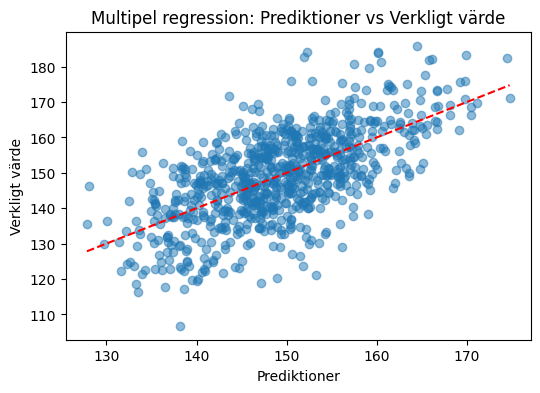

In [10]:
# --- Multipel regression ---
features = ['age', 'weight']
target = 'systolic_bp'

# Kör regression
reg_res = ha.regression_multiple(features, target)

# Visa koefficienter och intercept
print("Multipel regression: systolic_bp ~ age + weight")
print("Intercept:", round(reg_res['intercept'], 2))
for f, coef in reg_res['coefficients'].items():
    print(f"{f}: {coef:.3f}")

# Plotta prediktioner vs verkliga värden
ha.plot_regression_multiple(features, target)

### Kommentar: Multipel regression (systolic_bp ~ age + weight)

- **Intercept** (109.5): Basnivån för systoliskt blodtryck när både ålder och vikt är 0. I praktiken är detta mest teoretiskt.

- **Ålder** (0.539): Varje extra år ökar blodtrycket med ca 0.54 mmHg, givet samma vikt. Detta bekräftar det linjära samband du såg i enkel regression.

- **Vikt** (0.178): Varje extra kg ökar blodtrycket med ca 0.18 mmHg, givet samma ålder.

### Slutsats:  
- Både **ålder** och **vikt** bidrar tydligt till variationen i **systoliskt blodtryck**.

- Resultatet stämmer med tidigare observationer från enkel regression.
